# CSCE 676 Final Project Deliverable
*Yeshu Lokesh*

### Project Overview

The modern film industry relies on massive data to predict audience engagement, but these standard industry metrics create a feedback loop that highlights safe, repetitive blockbuster formulas (e.g., Action-Adventure, Romantic Comedies) while drowning out nuanced storytelling. Furthermore, gender representation is sometimes overlooked within certain genres in favor of financial gain.

To look beyond the industry baseline, I implemented a two-step pipeline designed to isolate and analyze "Representation Outliers." First, the pipeline utilizes a Multivariate Isolation Forest to detect structural anomalies, which is the subset of films that successfully break standard representation boundaries. Second, it deploys Apriori Association Rule Mining exclusively on this isolated subset to uncover their hidden genre combinations.

### Motivation & Research Question

Standard industry data is incredibly noisy and heavily skewed toward mathematically predictable formulas. The sheer volume of generic blockbusters drowns out nuanced, high-value films and they effectively erase the outliers of the dataset. Furthermore, discussions around gender representation in film, such as passing the Bechdel Test, aren't treated as a structural data problem. A film passes the Bechdel Test if it meets three rules: (1) it features at least two named women, (2) they talk to each other, (3) about something other than a man.

To understand the architecture of high-value representation, I have to filter out the "safe" industry noise. What is the underlying genre combination of the movies that successfully break standard structural formulas? To answer this, I deployed an anomaly detection model to isolate a subset of "Representation Outliers," allowing me to mine for the hidden genre rules.

Research Question: How do high-lift genre associations within representation outliers—isolated via a multivariate Isolation Forest—differ from those of the standard movie population?

### Phase 1: Setup
To build this hybrid pipeline, I will use `scikit-learn` for anomaly detection and `mlxtend` for association rule mining.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment setup complete.")

Environment setup complete.


### Phase 2: Data Loading & Preprocessing

The raw IMDb data in the dataset (sourced from Kaggle) uses the \N to denote missing values rather than standard nulls. Because of this, pandas initially reads columns like runtimeMinutes as categorical objects. The first preprocessing step is to replace these strings with np.nan and enforce numeric data types.

Step 1 of the pipeline is an Anomaly Detection task. While it's common practice to impute missing data, I chose not to so that I don't artificially pull anomalous movies toward the center of the statistical distribution, destroying the structural outliers I intend to isolate.

Therefore, I chose a filtration approach: dropping any movie missing important continuous data required for the pipeline. Out of the initial 9718 films, this removes 8 rows.

In [7]:
# Load dataset
df = pd.read_csv('data/Bechdel_IMDB_Merge0524.csv')

# Clean numerical columns for Anomaly Detection
df.replace('\\N', np.nan, inplace=True)
df['imdbAverageRating'] = pd.to_numeric(df['imdbAverageRating'])
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'])

# Drop rows missing critical numerical data for our pipeline
df_clean = df.dropna(subset=['imdbAverageRating', 'runtimeMinutes', 'bechdelRating']).copy()

print(f"Total valid movies ready for the pipeline: {len(df_clean)}")

Total valid movies ready for the pipeline: 9710


### Phase 3: Anomaly Detection & Hyperparameter Tuning

Instead of running an association rule mining algorithm across the entire dataset, I first segmented the movie population. To achieve this, I deployed a Multivariate Isolation Forest across three distinct dimensions: runtimeMinutes, imdbAverageRating, and bechdelRating.

Certain features of the dataset were skewed and didn't follow a standard normal distribution (e.g., runtimes cluster heavily around 90-120 minutes). Traditional anomaly detection methods like Z-scores or distance-based clustering (like K-Means) perform poorly on mixed, non-normalized data. Isolation Forest is the ideal choice because it isolates anomalies via random decision tree splits without relying on distance metrics.

I conducted sensitivity analysis testing to determine the best value for the contamination rate (1%, 5%, and 10%).


*   1% Contamination (98 movies): While these are the most extreme structural outliers, a subset of only 98 films is too sparse for Step 2 of the pipeline. The Apriori algorithm would struggle to find statistically significant, overlapping genre combinations in a sample this small.
*   10% Contamination (971 movies): With nearly 1000 files, the boundary is too loose, potentially diluting the outlier pool and effectively destroying the unique films I intend to isolate.
*   5% Contamination (486 movies): Here, I successfully isolated a robust, statistically significant subset of 486 true "Representation Outliers." This provides a large enough sample for the Apriori algorithm to mine frequent itemsets, while remaining strict enough to keep standard industry noise out.

In [10]:
features = ['imdbAverageRating', 'runtimeMinutes', 'bechdelRating']
test_rates = [0.01, 0.05, 0.10]

print("--- Isolation Forest Sensitivity Analysis ---")
for rate in test_rates:
    temp_forest = IsolationForest(contamination=rate, random_state=42)
    labels = temp_forest.fit_predict(df_clean[features])
    anomaly_count = (labels == -1).sum()
    print(f"Contamination Rate: {rate*100}% -> Identified {anomaly_count} anomalous movies.")

--- Isolation Forest Sensitivity Analysis ---
Contamination Rate: 1.0% -> Identified 98 anomalous movies.
Contamination Rate: 5.0% -> Identified 486 anomalous movies.
Contamination Rate: 10.0% -> Identified 971 anomalous movies.


### Phase 4: Final Model & Visualization

Based on the sensitivity analysis, I initialized the IsolationForest model with a contamination rate of 5%, in order to cleanly separate the dataset into two distinct groups - the "Standard Population" ($y = 1$) and the target "Representation Outliers" ($y = -1$).

I mapped the results onto a plot using two of the continuous features: Runtime and IMDb Rating.

The teal points form a tight, concentrated cluster in the center of the plot, proving that the vast majority of films cluster around mathematically safe formulas (e.g., 90 to 120-minute runtimes with average ratings between 5.5 and 7.5).

The coral points map to the extreme outliers of the dataset, some anomalies capture runtimes over 150+ minutes, critically acclaimed films with ratings over 8.5+, and experimental or poorly received outliers (ratings < 4.0). It's important to note that the model also factored in the Bechdel Score (0-3), therefore, some coral points lay slightly closer to the teal cluster. These are films where the structural anomaly is driven by their unique representation metrics rather than just their runtime or rating alone.

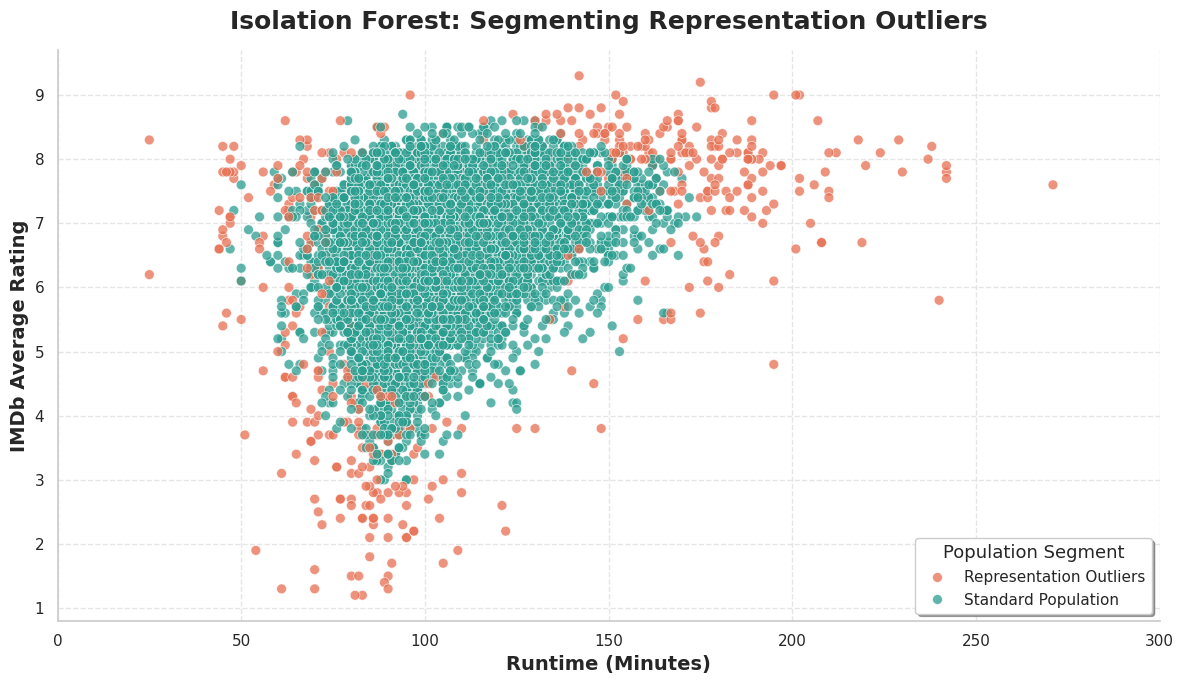

In [11]:
# Fit the final model at 5%
final_forest = IsolationForest(contamination=0.05, random_state=42)
df_clean['anomaly_label'] = final_forest.fit_predict(df_clean[features])

# Split the data
df_anomalies = df_clean[df_clean['anomaly_label'] == -1]
df_normal = df_clean[df_clean['anomaly_label'] == 1]

plt.figure(figsize=(12, 7))

custom_palette = {1: '#2A9D8F', -1: '#E76F51'} # Teal for normal, vibrant Coral for anomalies

ax = sns.scatterplot(
    data=df_clean,
    x='runtimeMinutes',
    y='imdbAverageRating',
    hue='anomaly_label',
    palette=custom_palette,
    alpha=0.75,
    s=50,
    edgecolor='white',
    linewidth=0.5
)

plt.title('Isolation Forest: Segmenting Representation Outliers', fontsize=18, fontweight='800', pad=15)
plt.xlabel('Runtime (Minutes)', fontsize=14, fontweight='600')
plt.ylabel('IMDb Average Rating', fontsize=14, fontweight='600')

handles, labels = ax.get_legend_handles_labels()

# Since -1 (Anomaly) sorts before 1 (Normal), must list 'Anomalous' first
ax.legend(handles=handles, labels=['Representation Outliers', 'Standard Population'],
          title='Population Segment', title_fontsize='13', fontsize='11',
          loc='lower right', frameon=True, shadow=True)

plt.xlim(0, 300)
sns.despine()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('anomaly_visualization.png', dpi=300)
plt.show()

### Phase 5: Frequent Pattern Mining

Now that the two populations are successfully isolated (486 outliers vs. 9224 standard films), I was able to proceed to the second part of this pipeline.

The Apriori algorithm can't read continuous variable and requires a binary matrix. I used a `TransactionEncoder` to transform the categorical text data (genres) into a One-Hot Encoded Matrix. To achieve this, I cleaned the transaction baskets by stripping out any  NaN or \N strings. Then, I used mlxtend's TransactionEncoder to transform the three categorical genre columns into a One-Hot Encoded Matrix. Every movie becomes a "transaction," and every genre becomes an "item."

When running Apriori across two differently sized populations, using a generalized min_support threshold will lead to incorrect conclusions.

For the Standard Population, I set min_support = 0.05, as this group contains over 9,200 movies, a 5% threshold requires a genre combination to appear in roughly 460 films to be considered frequent for filtering out noise within this massive dataset.

For the Representation Outliers, I lowered the threshold to min_support = 0.03, as this subset is highly concentrated (only 486 films), forcing a 5% support would prematurely filter out the rare, highly correlated genre combinations I intended to uncover.

Once the frequent itemsets are generated, I evaluated the strength of the association rules, prioritizing Lift over Confidence. Confidence can be highly misleading in movie datasets because certain genres (like Drama) are generally popular. By using Lift, I specifically isolated genres that have a high correlation to one another, accounting for their baseline frequencies.

In [12]:
def prepare_genre_transactions(dataframe):
    """Formats genre columns into a One-Hot Encoded matrix for Apriori."""
    genre_data = dataframe[['genre1', 'genre2', 'genre3']].dropna(how='all')
    transactions = genre_data.values.tolist()

    # Clean the transaction baskets (remove NaNs)
    transactions = [[str(g) for g in movie if pd.notna(g) and str(g) not in ['nan', '\\N']] for movie in transactions]

    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    return pd.DataFrame(te_ary, columns=te.columns_)

def get_top_rules(encoded_df, min_support, min_lift=1.0):
    """Runs Apriori and extracts association rules sorted by Lift, removing redundant rules."""
    frequent_itemsets = apriori(encoded_df, min_support=min_support, use_colnames=True)
    if len(frequent_itemsets) == 0:
        return pd.DataFrame()

    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_lift)

    # 1. Create a combined set of all items in the rule to identify duplicates
    rules['total_itemset'] = rules.apply(lambda row: row['antecedents'].union(row['consequents']), axis=1)

    # 2. Sort by Lift first, then by Confidence to ensure we keep the strongest directional rule
    rules = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

    # 3. Drop all subsequent rules that share the exact same total_itemset, keeping only the first (best) one
    rules = rules.drop_duplicates(subset=['total_itemset'], keep='first')

    rules = rules.drop(columns=['total_itemset'])

    return rules

# Encode both sets
encoded_normal = prepare_genre_transactions(df_normal)
encoded_anomalies = prepare_genre_transactions(df_anomalies)

# Generate Rules (Using lower support for anomalies due to smaller sample size)
normal_rules = get_top_rules(encoded_normal, min_support=0.05, min_lift=1.0)
anomaly_rules = get_top_rules(encoded_anomalies, min_support=0.03, min_lift=1.0)

print("Apriori algorithm executed successfully on both subsets.")

Apriori algorithm executed successfully on both subsets.


### Phase 6: Results & Analysis

With the association rules generated, I compared the genre combinations of the two segments, specifically the Lift Disparity which signifies the difference in correlation strength between the standard films and the isolated outliers.

By sorting both sets of rules by their highest Lift scores, there's a very clear contrast:

1. The Standard

*   The industry baseline is governed by highly generic and safe pairings.The strongest association is Adventure $\rightarrow$ Action, which achieves a Lift of 2.53x. However, outside of that single blockbuster trope, the rest of the rules drop off immediately into statistical noise. Pairings like Biography $\rightarrow$ Drama (1.53x Lift) and Romance $\rightarrow$ Comedy (1.34x Lift) hover extremely close to the baseline. For example, a 1.03x lift for Crime & Drama means those genres appear together as if it were random chance.


2. The Outliers


*   The top rule governing the outliers is the combination of (Drama + Biography) $\rightarrow$ History. While this specific combination has a smaller overall effect within the subset (Support = ~3.3%), its correlation strength is extremely high with a Lift of 6.16x. Furthermore, the anomaly subset reveals completely different secondary patterns. For instance, Sci-Fi $\rightarrow$ Horror emerges with a strong 2.87x Lift—a structural pairing that doesn't even make the top 5 in the normal population.

This data empirically proves my assumption that the standard movie industry relies on a high-support, low-lift strategy, generally releasing mildly correlated action and comedy tropes to cast the widest possible net. In contrast, high-value representation is driven by a low-support, massive-lift strategy. To break structural norms, outlier cinema breaks away from safe formulas and relies on highly specific, tightly bound sub-genres, specifically complex historical narratives and thrillers.


In [13]:
print("=========================================================")
print("TOP 5 GENRE RULES: THE 'NORMAL' MOVIES")
print("=========================================================")
display(normal_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

print("\n")

print("=========================================================")
print("TOP 5 GENRE RULES: THE STRUCTURAL ANOMALIES")
print("=========================================================")
display(anomaly_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

TOP 5 GENRE RULES: THE 'NORMAL' MOVIES


,antecedents,consequents,support,confidence,lift
0,(Adventure),(Action),0.084571,0.493984,2.538167
3,(Biography),(Drama),0.050201,0.878558,1.536976
5,(Romance),(Comedy),0.093570,0.510651,1.344486
9,(Romance),(Drama),0.132061,0.720710,1.260832
7,(Crime),(Drama),0.088908,0.589080,1.030556




TOP 5 GENRE RULES: THE STRUCTURAL ANOMALIES


,antecedents,consequents,support,confidence,lift
28,"(Drama, Biography)",(History),0.032990,0.444444,6.158730
13,(History),(Biography),0.032990,0.457143,5.992278
26,(Sci-Fi),(Horror),0.032990,0.355556,2.874074
0,(Adventure),(Action),0.115464,0.491228,2.108368
14,(Comedy),(Family),0.039175,0.163793,2.090517


### Phase 7: Conclusion

By isolating structural anomalies from the broader cinematic landscape and conducting association rule mining on both subsets, I observed a massive Lift Disparity, demonstrating that the underlying genre combinations governing these two populations are fundamentally different in kind.

These findings quantitatively prove that sticking to standard blockbuster averages actively suppresses complex representation. Within the representation outliers, the Drama-Biography-History trifecta occurs over six times more frequently than baseline probabilities, showing a level of  correlation which is missing from the industry.

For film studios, producers, and data analysts looking to capture untapped audiences, this project offers a clear perspective. Intentionally straying from the safety of the low-lift, safe formulas and investing in the complex, highly niche narratives that drive cinematic outliers is likely to capture dedicated audiences who are eager for genuine, complex representation rather than recycled blockbuster tropes.

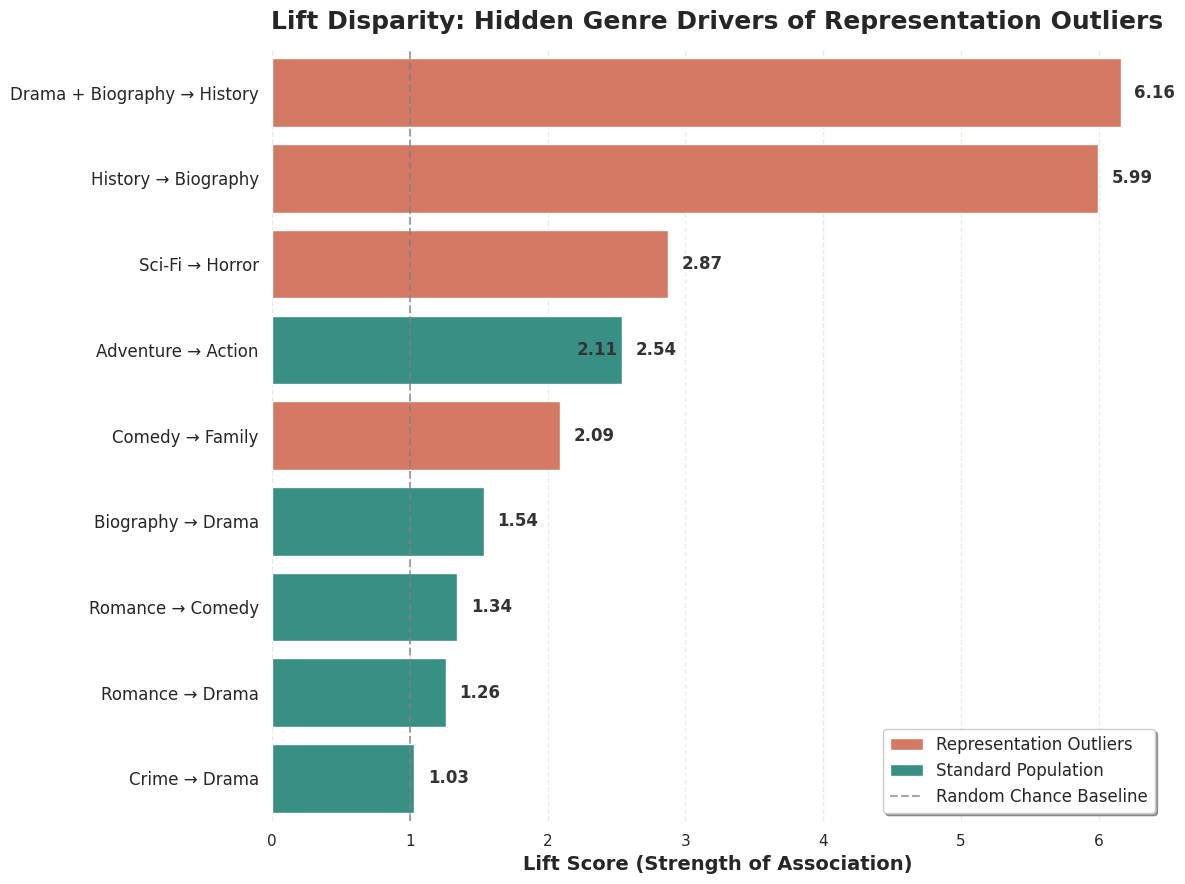

In [14]:
top_normal = normal_rules.head(5).copy()
top_anomaly = anomaly_rules.head(5).copy()

def format_rule_label(row):
    ant = " + ".join(list(row['antecedents']))
    con = " + ".join(list(row['consequents']))
    return f"{ant} \u2192 {con}"

top_normal['Rule'] = top_normal.apply(format_rule_label, axis=1)
top_anomaly['Rule'] = top_anomaly.apply(format_rule_label, axis=1)

# Assign Population Types
top_normal['Type'] = 'Standard Population'
top_anomaly['Type'] = 'Representation Outliers'

combined_rules = pd.concat([top_anomaly, top_normal]).sort_values(by='lift', ascending=False)

plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=combined_rules,
    x='lift',
    y='Rule',
    hue='Type',
    dodge=False,
    palette={'Standard Population': '#2A9D8F', 'Representation Outliers': '#E76F51'}
)

plt.title('Lift Disparity: Hidden Genre Drivers of Representation Outliers', fontsize=18, fontweight='800', pad=15)
plt.xlabel('Lift Score (Strength of Association)', fontsize=14, fontweight='600')
plt.ylabel('', fontsize=14)

plt.axvline(x=1, color='gray', linestyle='--', alpha=0.7, label='Random Chance Baseline')

# Data Labels (Skipping zeros)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        plt.text(width + 0.1, p.get_y() + p.get_height()/2, f'{width:.2f}',
                 ha='left', va='center', fontsize=12, fontweight='bold', color='#333333')

plt.legend(loc='lower right', fontsize='12', frameon=True, shadow=True)
sns.despine(left=True, bottom=True)
ax.tick_params(axis='y', labelsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('lift_disparity_chart_top5.png', dpi=300)
plt.show()

On my honor, I declare the following resources:
1. Collaborators:
- NA

2. Web Sources:
- NA

3. AI Tools:
- Some lines of code were auto-completed by Colab
- Gemini: I used it to generate the code for this project, reprompting several times to process the data, handle edge cases and optimize data structures correctly. I also prompted it to refine my explanations for each phase.